In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ========================================
# CELL 2: Load the Iris Dataset
# ========================================
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for easier handling
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# ========================================
# CELL 3: Basic Data Exploration
# ========================================
print("="*50)
print("DATASET SHAPE")
print("="*50)
print(f"Shape: {df.shape} (rows, columns)\n")

print("="*50)
print("DATA TYPES AND INFO")
print("="*50)
print(df.info(), "\n")

print("="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print(df.describe(), "\n")

print("="*50)
print("SPECIES DISTRIBUTION")
print("="*50)
print(df['species'].value_counts())

DATASET SHAPE
Shape: (150, 5) (rows, columns)

DATA TYPES AND INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None 

STATISTICAL SUMMARY
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             

<Figure size 1200x1000 with 0 Axes>

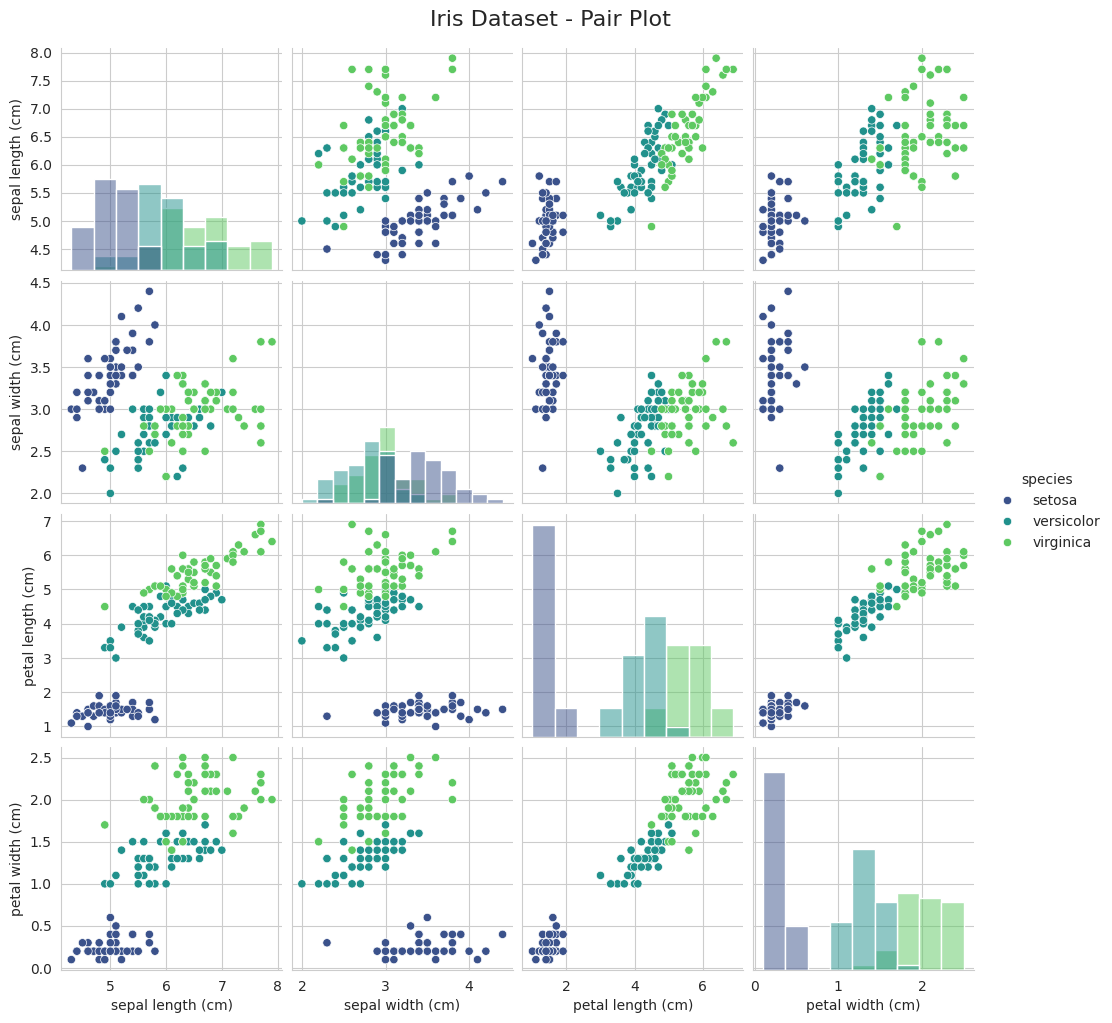

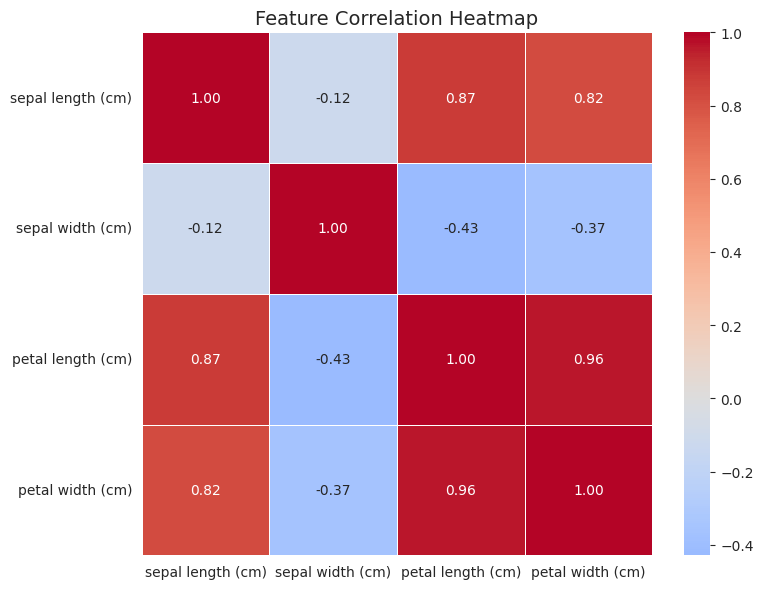

In [4]:
# ========================================
# CELL 4: Data Visualization
# ========================================
sns.set_style("whitegrid")

# Pairplot to see relationships between features
plt.figure(figsize=(12,10))
sns.pairplot(df, hue='species', palette='viridis', diag_kind='hist')
plt.suptitle('Iris Dataset - Pair Plot', y=1.02, fontsize=16)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
corr = df.iloc[:,:4].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# ========================================
# CELL 5: Split Data into Train and Test Sets
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"\nTrain/Test split ratio: {len(X_train)}/{len(X_test)} = {len(X_train)/len(X_test):.1f}")

Training set size: 120 samples
Test set size: 30 samples

Train/Test split ratio: 120/30 = 4.0


In [6]:
# ========================================
# CELL 6: Train Multiple Classification Models
# ========================================

# Initialize three different classification models
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors (K=5)': KNeighborsClassifier(n_neighbors=5)
}

# Train each model and calculate accuracy
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f} ({acc*100:.2f}%)")

Logistic Regression: Accuracy = 0.9667 (96.67%)
Random Forest: Accuracy = 0.9000 (90.00%)
K-Nearest Neighbors (K=5): Accuracy = 1.0000 (100.00%)


BEST MODEL: K-Nearest Neighbors (K=5)
Best Accuracy: 1.0000 (100.00%)


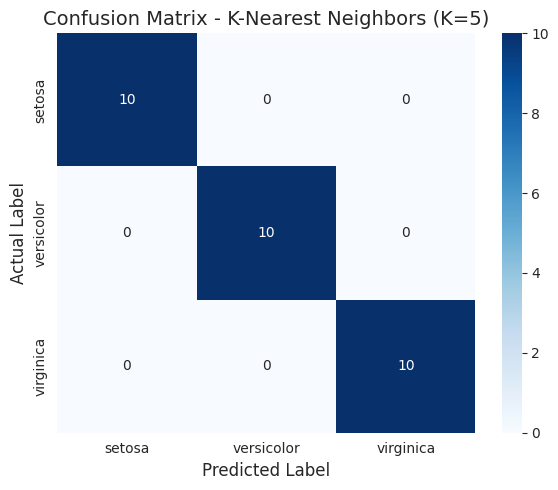


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [7]:
# ========================================
# CELL 7: Evaluate the Best Model
# ========================================

# Find the best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print("="*50)
print(f"BEST MODEL: {best_model_name}")
print(f"Best Accuracy: {results[best_model_name]:.4f} ({results[best_model_name]*100:.2f}%)")
print("="*50)

# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

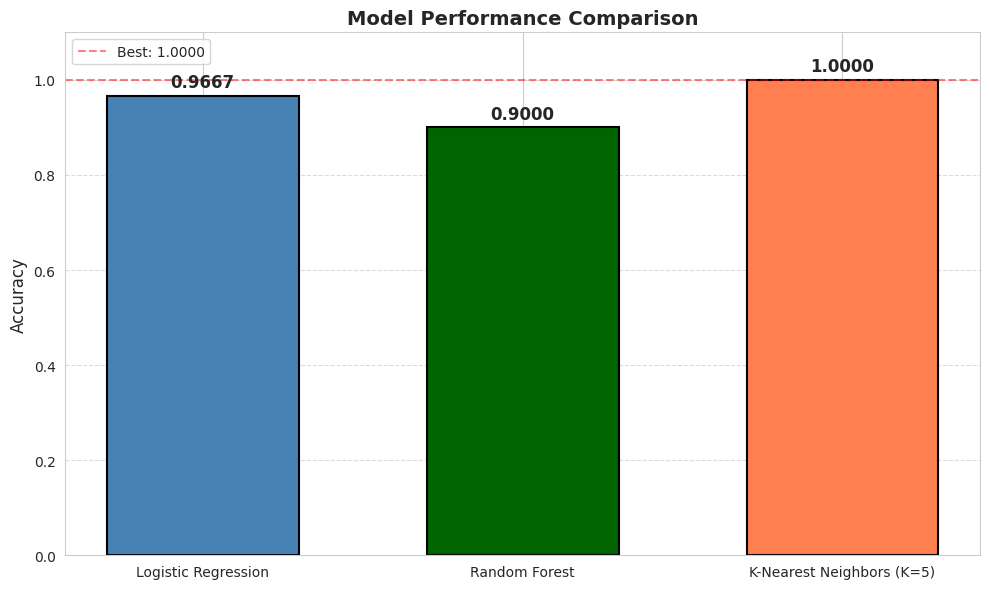

In [8]:
# ========================================
# CELL 8: Compare All Models - Bar Chart
# ========================================

plt.figure(figsize=(10,6))
model_names = list(results.keys())
accuracies = list(results.values())
colors = ['steelblue', 'darkgreen', 'coral']

bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=max(accuracies), color='red', linestyle='--', alpha=0.5, label=f'Best: {max(accuracies):.4f}')
plt.legend()
plt.tight_layout()
plt.show()

Feature Importance (Random Forest):
          Feature  Importance
 sepal width (cm)      0.0150
sepal length (cm)      0.1163
petal length (cm)      0.4315
 petal width (cm)      0.4372


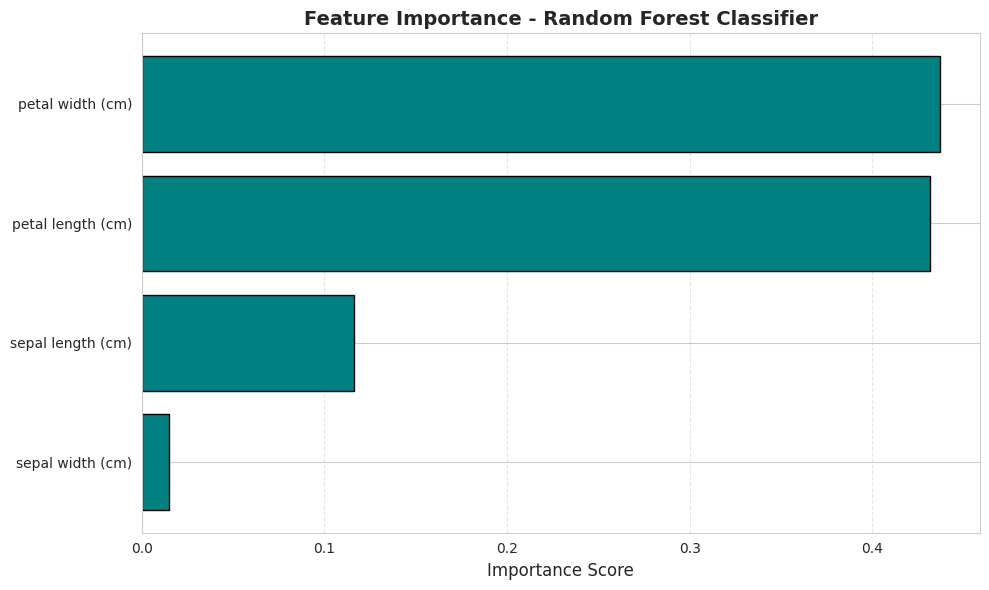

In [9]:
# ========================================
# CELL 9: Feature Importance (Random Forest)
# ========================================

# Get feature importances from Random Forest
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = iris.feature_names

# Create a DataFrame for feature importance
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

print("Feature Importance (Random Forest):")
print(feature_imp_df.round(4).to_string(index=False))

# Horizontal bar plot
plt.figure(figsize=(10,6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='teal', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# ========================================
# CELL 10: Conclusion
# ========================================

print("="*60)
print("                    PROJECT CONCLUSION")
print("="*60)

print(f"""
1. DATASET: Iris Flower Dataset
   - 150 samples, 4 features, 3 classes (Setosa, Versicolor, Virginica)
   - Features: Sepal Length, Sepal Width, Petal Length, Petal Width

2. BEST MODEL: {best_model_name}
   - Achieved {results[best_model_name]:.4f} ({results[best_model_name]*100:.2f}%) accuracy

3. MODEL COMPARISON:
   - Logistic Regression:     {results['Logistic Regression']:.4f} ({results['Logistic Regression']*100:.2f}%)
   - Random Forest:           {results['Random Forest']:.4f} ({results['Random Forest']*100:.2f}%)
   - K-Nearest Neighbors:     {results['K-Nearest Neighbors (K=5)']:.4f} ({results['K-Nearest Neighbors (K=5)']*100:.2f}%)

4. KEY INSIGHTS:
   - All three models performed very well on this dataset.
   - Petal length and petal width are the most important features.
   - Sepal measurements are less discriminative for classification.
   - The Iris dataset is well-separated, making it easy for ML models.

5. CONCLUSION:
   The trained model can accurately predict the species of an Iris flower
   based on its sepal and petal measurements with over {max(accuracies)*100:.0f}% accuracy.
""")

print("="*60)
print("             END OF NOTEBOOK")
print("="*60)

                    PROJECT CONCLUSION

1. DATASET: Iris Flower Dataset
   - 150 samples, 4 features, 3 classes (Setosa, Versicolor, Virginica)
   - Features: Sepal Length, Sepal Width, Petal Length, Petal Width

2. BEST MODEL: K-Nearest Neighbors (K=5)
   - Achieved 1.0000 (100.00%) accuracy

3. MODEL COMPARISON:
   - Logistic Regression:     0.9667 (96.67%)
   - Random Forest:           0.9000 (90.00%)
   - K-Nearest Neighbors:     1.0000 (100.00%)

4. KEY INSIGHTS:
   - All three models performed very well on this dataset.
   - Petal length and petal width are the most important features.
   - Sepal measurements are less discriminative for classification.
   - The Iris dataset is well-separated, making it easy for ML models.

5. CONCLUSION:
   The trained model can accurately predict the species of an Iris flower
   based on its sepal and petal measurements with over 100% accuracy.

             END OF NOTEBOOK
